# Abalone Age Prediction using Machine Learning 

## Problem Type: Supervised Machine Learning 
## Dataset : UCI Abalone Dataset 
## Target Varibale : Age (Rings + 1.5)
## Models used : 
### - Linear Regression 
### - Random Forest Regressor 
### - Support Vector Regressor (SVR) 

## Evaluation Metrics 
### - MAE 
### - RMSE 
### - R^2 Score 

# Import libraries

In [4]:
import pandas as pd 
import numpy as np 

# visualization tools 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Base line model 
from sklearn.dummy import DummyRegressor

# ignore warnings 
import warnings
warnings.filterwarnings("ignore")

## Dataset Loaded & Columns Manually Added

In [6]:
# define columns as our dataset dont have columns 
columns = ["Sex", "Length", "Diameter", "Height","Whole_weight", "Shucked_weight","Viscera_weight", "Shell_weight", "Rings"]

# load dataset 
df = pd.read_csv("abalone.csv", header=None, names=columns)

## Understanding Dataset - Exploratory Data analysis (EDA)

In [8]:
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [9]:
df.tail()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
4172,F,0.565,0.450,0.165,0.8870,0.3700,0.2390,0.2490,11
4173,M,0.590,0.440,0.135,0.9660,0.4390,0.2145,0.2605,10
4174,M,0.600,0.475,0.205,1.1760,0.5255,0.2875,0.3080,9
4175,F,0.625,0.485,0.150,1.0945,0.5310,0.2610,0.2960,10
4176,M,0.710,0.555,0.195,1.9485,0.9455,0.3765,0.4950,12


In [10]:
df.dtypes

Sex                object
Length            float64
Diameter          float64
Height            float64
Whole_weight      float64
Shucked_weight    float64
Viscera_weight    float64
Shell_weight      float64
Rings               int64
dtype: object

In [11]:
df.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole_weight    4177 non-null   float64
 5   Shucked_weight  4177 non-null   float64
 6   Viscera_weight  4177 non-null   float64
 7   Shell_weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [13]:
df.shape

(4177, 9)

In [14]:
df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [15]:
df.isnull().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

In [16]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
4172    False
4173    False
4174    False
4175    False
4176    False
Length: 4177, dtype: bool

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df['Rings'].describe()

count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: Rings, dtype: float64

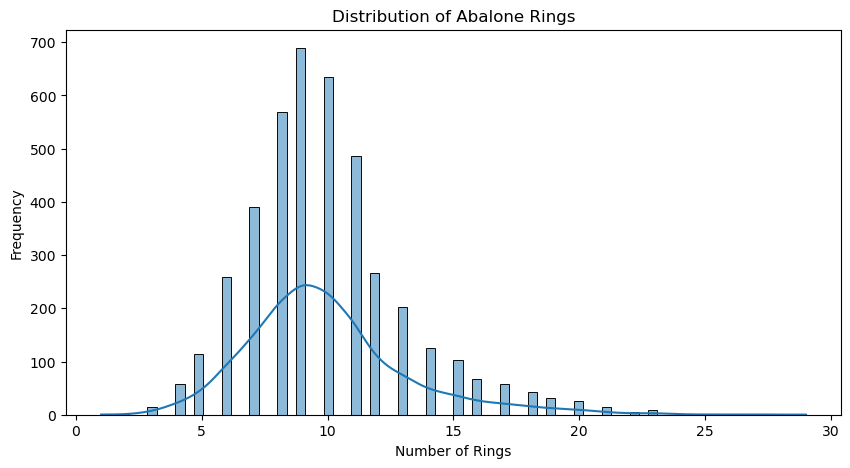

In [19]:
# distributiono of rings 
plt.figure(figsize=(10,5))
sns.histplot(df["Rings"], kde=True)
plt.xlabel("Number of Rings")
plt.ylabel("Frequency")
plt.title("Distribution of Abalone Rings")
plt.show()

In [20]:
# Create target variable 
df["Age"] = df["Rings"] + 1.5 

In [21]:
df[["Rings","Age"]].head()

,Rings,Age
0,15,16.5
1,7,8.5
2,9,10.5
3,10,11.5
4,7,8.5


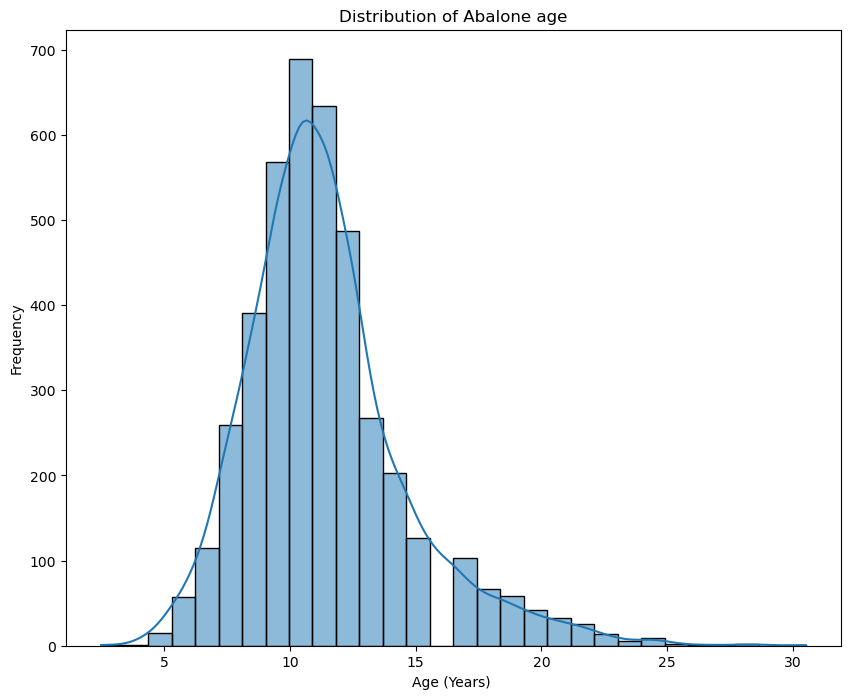

In [22]:
# target variable distribution 
plt.figure(figsize=(10,8))
sns.histplot(df["Age"],bins=30 ,kde=True)
plt.title("Distribution of Abalone age")
plt.xlabel("Age (Years) ")
plt.ylabel("Frequency")
plt.show()

In [23]:
df["Age"].max()

30.5

In [24]:
df["Age"].min()

2.5

In [25]:
df["Age"].mean()

np.float64(11.433684462532918)

In [26]:
 # Distribution of Sex (Categorical Feature)
df["Sex"].value_counts()

Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64

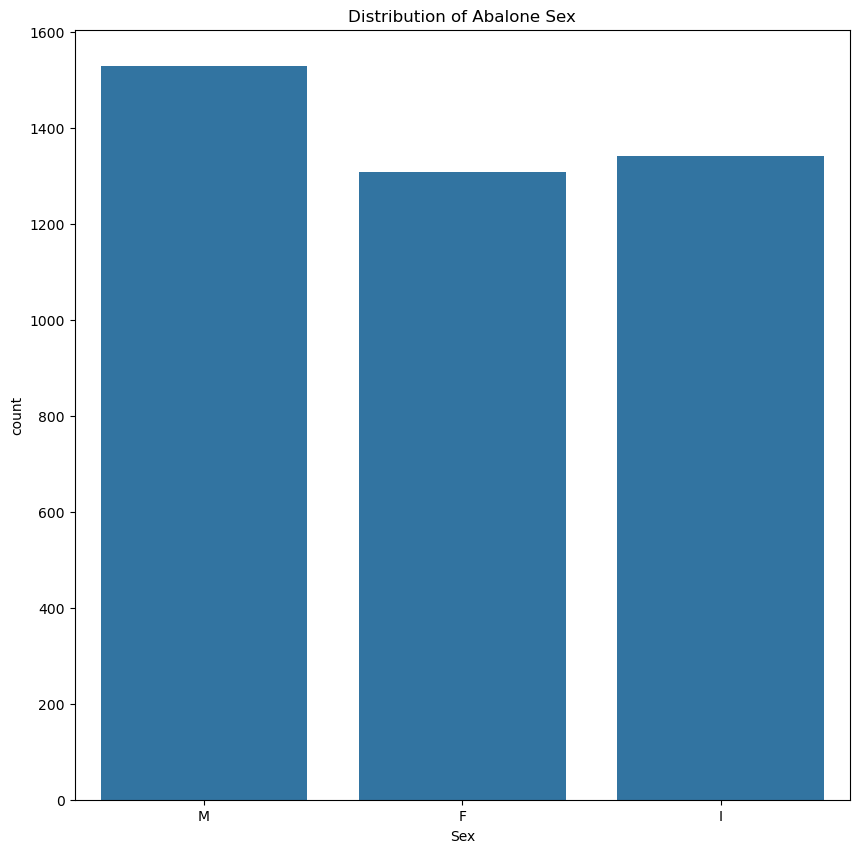

In [27]:
# Sex Distribution
plt.figure(figsize=(10,10))
sns.countplot(x = df["Sex"],data=df )
plt.title("Distribution of Abalone Sex")
plt.show()

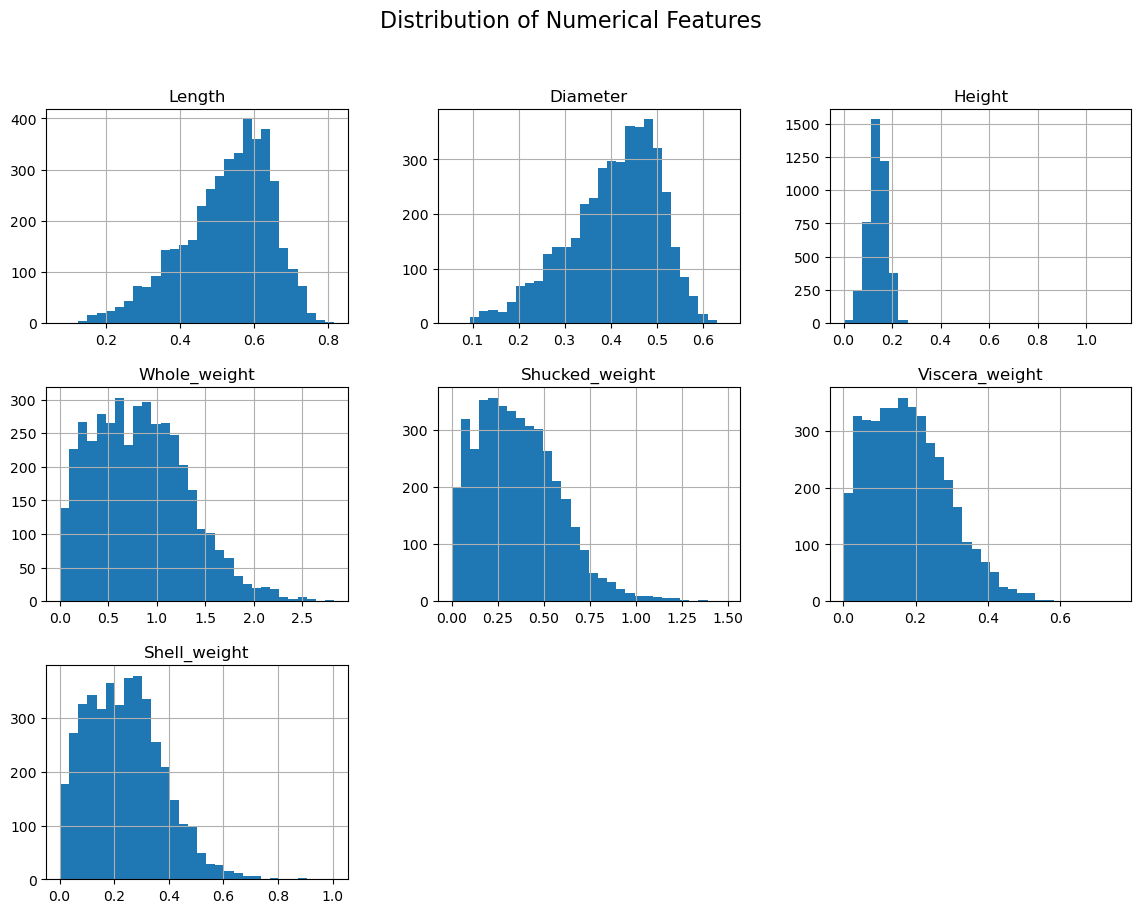

In [28]:
df.drop(columns=["Rings", "Age"]).hist(
    figsize=(14, 10),
    bins=30,
)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()

## Feature vs target scatter plot 

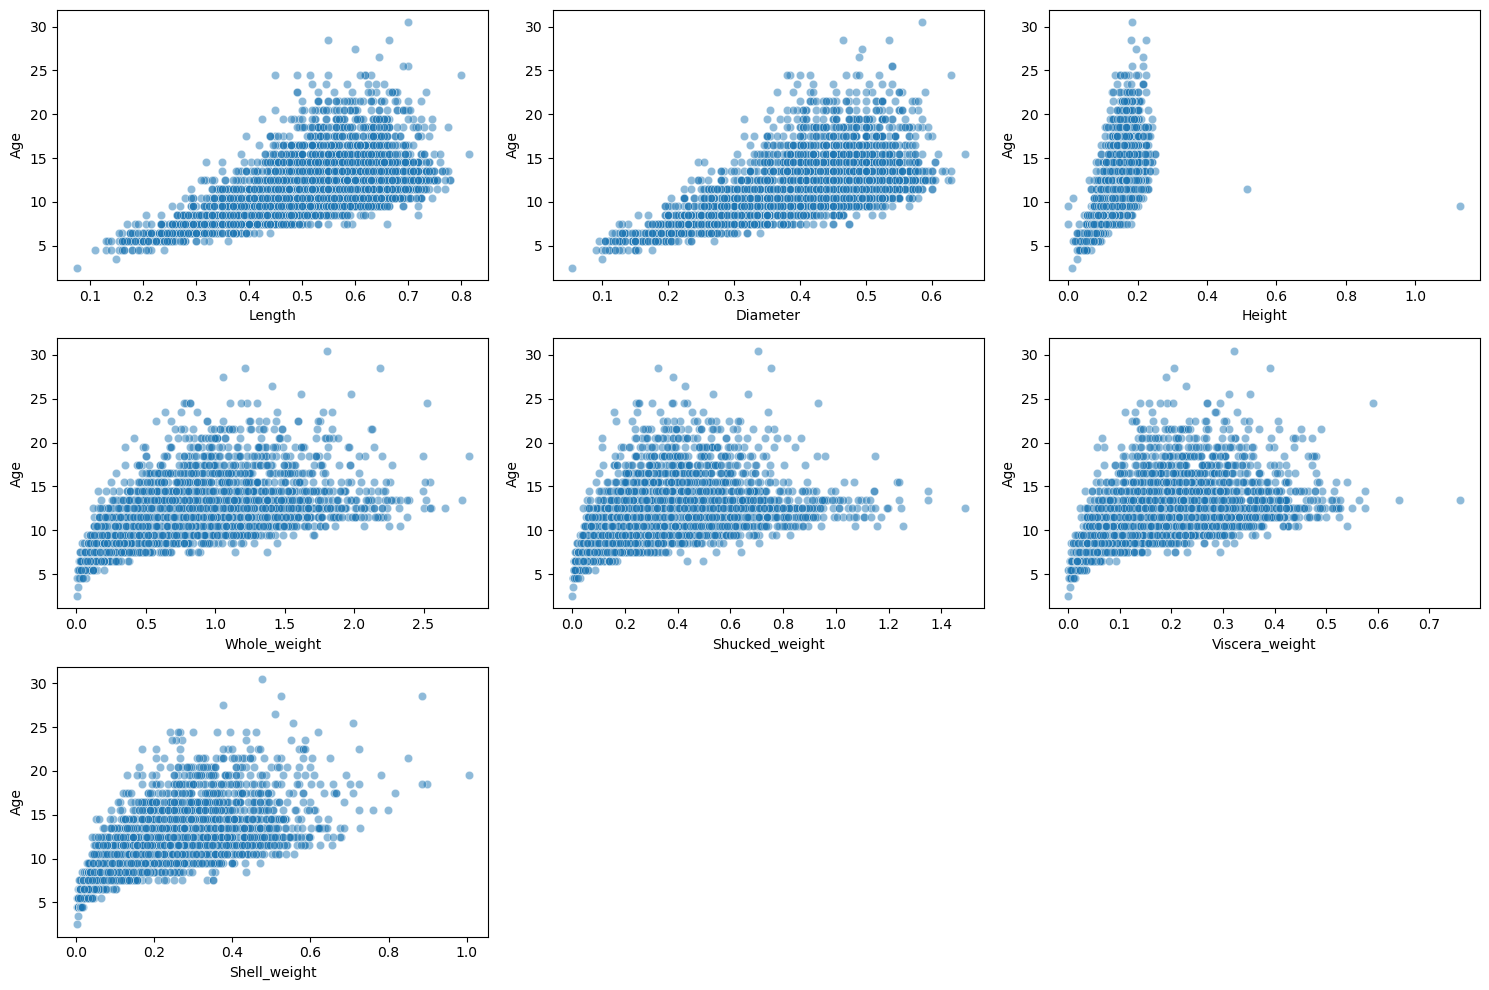

In [30]:
numerical_features = [
    "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight",
    "Viscera_weight", "Shell_weight"
]

plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(3, 3, i)
    sns.scatterplot(x=df[feature], y=df["Age"], alpha=0.5)
    plt.xlabel(feature)
    plt.ylabel("Age")

plt.tight_layout()
plt.show()

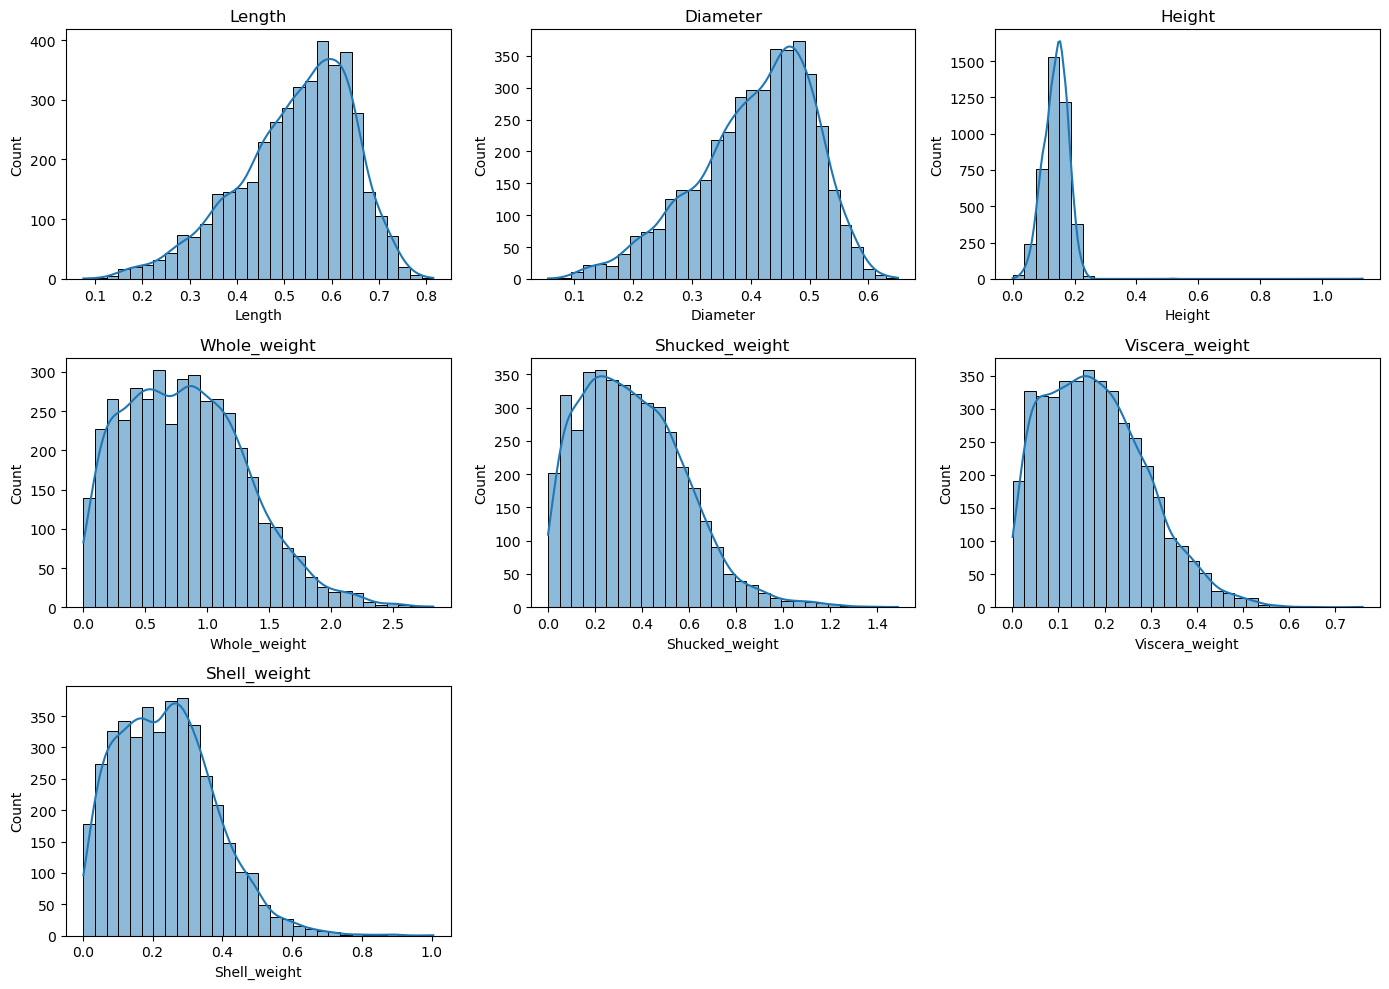

In [31]:
# Feature distribution analysis
num_features = [
    "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight",
    "Viscera_weight", "Shell_weight"
]

plt.figure(figsize=(14, 10))

for i, col in enumerate(num_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

## Correlation heatmap 

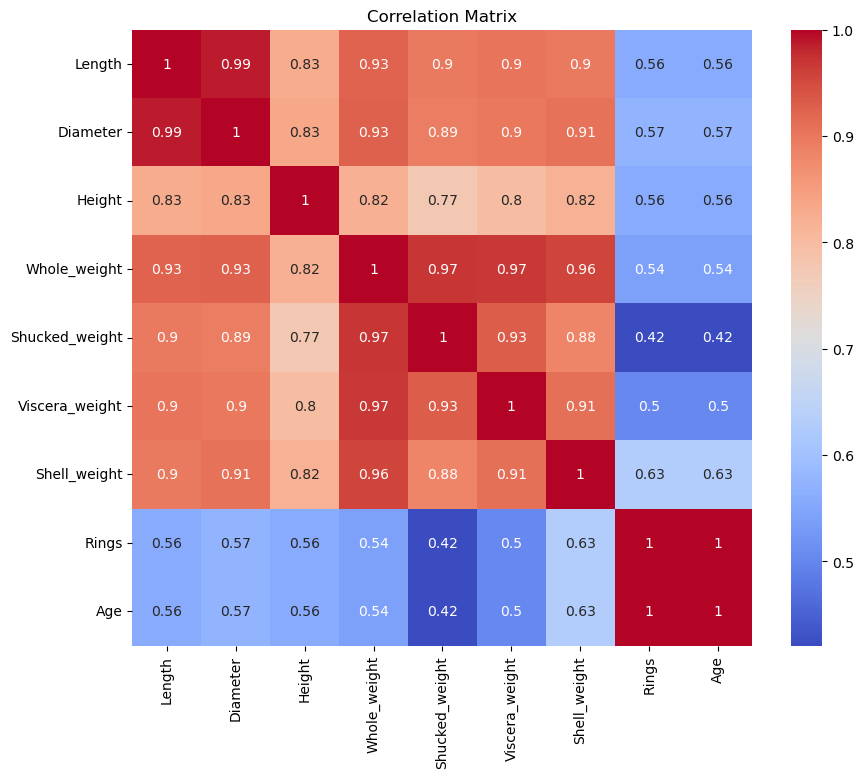

In [33]:
plt.figure(figsize=(10, 8))

numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

## Detecting outlier in numerical features 

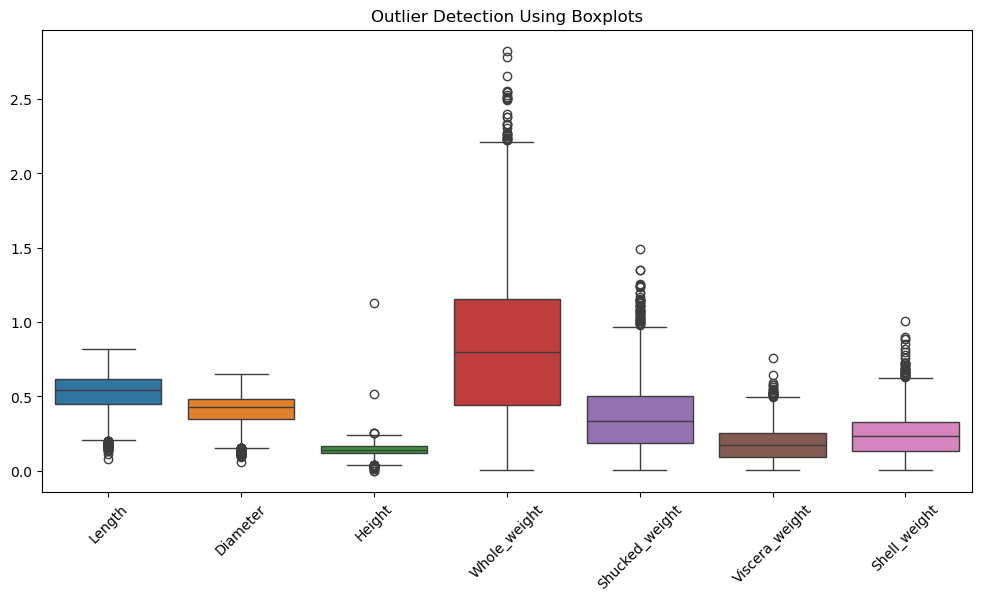

In [35]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[numerical_features])
plt.xticks(rotation=45)
plt.title("Outlier Detection Using Boxplots")
plt.show()

# Handle Categorical Data

In [37]:
df.select_dtypes(include=["object"]).columns

Index(['Sex'], dtype='object')

In [38]:
df["Sex"].value_counts()

Sex
M    1528
I    1342
F    1307
Name: count, dtype: int64

In [39]:
# The distribution of categories in the `Sex` feature was examined before encoding.
# All categories have sufficient representation, making them suitable for one-hot encoding without causing data imbalance issues.

In [40]:
# Why one hot encding was used :
# "Sex" feature is nominal categorical variable that means it doesnto have order , there is no order between male, femal , infant 
# Assigning 0,1,2 will be false ordering 
# Thats why one hot encoding was selected because it creates separate binary columns for each category  

In [41]:
df_encoded = pd.get_dummies(df, columns=["Sex"], drop_first=True) # drop first is used to avoid multi collinearity 

In [42]:
df_encoded.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Age,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,16.5,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,8.5,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,10.5,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,11.5,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,8.5,True,False


In [43]:
df_encoded.shape

(4177, 11)

In [44]:
df_encoded.columns

Index(['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings', 'Age', 'Sex_I', 'Sex_M'],
      dtype='object')

# FEATURE SELECTION

In [46]:
y  = df_encoded["Age"]

In [47]:
X = df_encoded.drop(columns=["Rings","Age"], axis=1)

In [48]:
X.head()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,False,True
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,False,True
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,False,False
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,False,True
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,True,False


In [49]:
X.shape, y.shape

((4177, 9), (4177,))

In [50]:
# both x and y have same number of samples 

### Final sanity check 

In [52]:
X.select_dtypes(include=["object"]).columns

Index([], dtype='object')

In [53]:
# A final data type check was conducted to check if all the features are numeric or boolean before feeding data to any machine learning model 

# TRAIN–TEST SPLIT

In [55]:
# Perform the Split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [56]:
# Verify the split 
X_train.shape, X_test.shape 

((3341, 9), (836, 9))

# FEATURE SCALING

In [58]:
# Applying Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scales = scaler.transform(X_test)

### Checkng target distribution  after split 

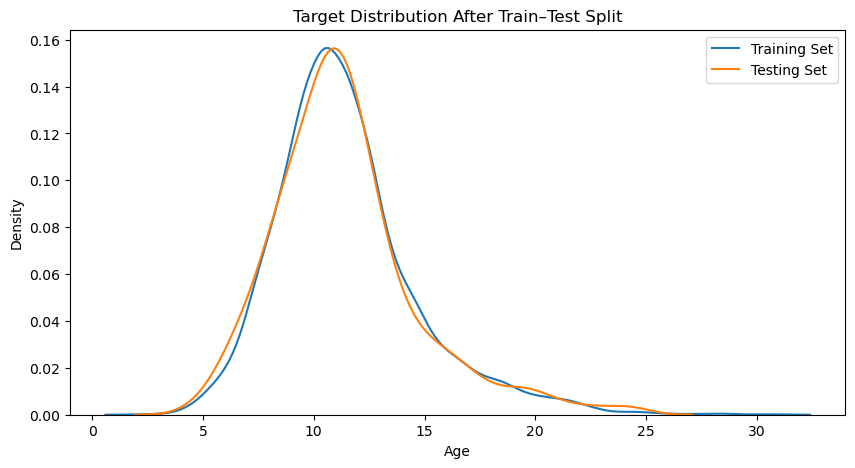

In [60]:
plt.figure(figsize=(10, 5))
sns.kdeplot(y_train, label="Training Set")
sns.kdeplot(y_test, label="Testing Set")
plt.title("Target Distribution After Train–Test Split")
plt.xlabel("Age")
plt.legend()
plt.show()

## Feature scaling 

In [62]:
scaler = StandardScaler()

In [63]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
# Converting scaled data to dataframe
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

X_train_scaled_df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Sex_I,Sex_M
count,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03,3.341000e+03
mean,5.635852e-16,2.041667e-16,-3.105036e-16,-1.063368e-17,2.530817e-16,1.680122e-16,1.828994e-16,4.678821e-17,2.126737e-17
std,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00,1.000150e+00
min,-3.777412e+00,-3.582758e+00,-3.288610e+00,-1.686311e+00,-1.612494e+00,-1.647965e+00,-1.702271e+00,-6.887701e-01,-7.589093e-01
25%,-6.293175e-01,-5.930591e-01,-5.832029e-01,-7.890755e-01,-7.805961e-01,-8.026546e-01,-7.838882e-01,-6.887701e-01,-7.589093e-01
50%,1.681999e-01,1.670339e-01,4.928971e-03,-5.867303e-02,-1.056604e-01,-8.985185e-02,-4.060562e-02,-6.887701e-01,-7.589093e-01
75%,7.558443e-01,7.244354e-01,5.930609e-01,6.513840e-01,6.410292e-01,6.640741e-01,6.347810e-01,1.451863e+00,1.317680e+00
max,2.434828e+00,2.447313e+00,2.329495e+01,4.058233e+00,5.056140e+00,5.292723e+00,5.469691e+00,1.451863e+00,1.317680e+00


In [65]:
### Scaling Verification

# After scaling, the summary statistics of the training data were examined.
# The mean of each feature is approximately 0 and the standard deviation is approximately 1, confirming that standardization was applied correctly.

# BASELINE MODEL (Dummy Regressor)

In [67]:
dummy_reg = DummyRegressor(strategy="mean")
dummy_reg.fit(X_train, y_train)

,strategy,'mean'
,constant,None
,quantile,None


In [68]:
y_dummy_pred = dummy_reg.predict(X_test)

### Evaluate baseline model 

In [70]:
dummy_mae = mean_absolute_error(y_test, y_dummy_pred)
dummy_rmse = np.sqrt(mean_squared_error(y_test, y_dummy_pred))
dummy_r2 = r2_score(y_test, y_dummy_pred)

dummy_mae, dummy_rmse, dummy_r2

(2.3847700528020006, np.float64(3.290622953710525), -0.00027614964665212405)

# MODEL TRAINING

## Linear Regression Training

In [73]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
y_lr_pred = lr_model.predict(X_test_scaled)

In [75]:
lr_mae = mean_absolute_error(y_test, y_lr_pred)
lr_rmse =np.sqrt(mean_squared_error(y_test, y_lr_pred))
lr_r2 = r2_score(y_test, y_lr_pred)

lr_mae, lr_rmse, lr_r2

(1.5931067816608362, np.float64(2.2116130871218367), 0.5481628137889263)

In [76]:
lr_coefficients = pd.Series(lr_model.coef_, index=X_train.columns).sort_values(ascending=False)

lr_coefficients

Whole_weight      4.390252
Shell_weight      1.230228
Diameter          1.097569
Height            0.444004
Sex_M             0.049734
Length           -0.024009
Sex_I            -0.335870
Viscera_weight   -1.046005
Shucked_weight   -4.516890
dtype: float64

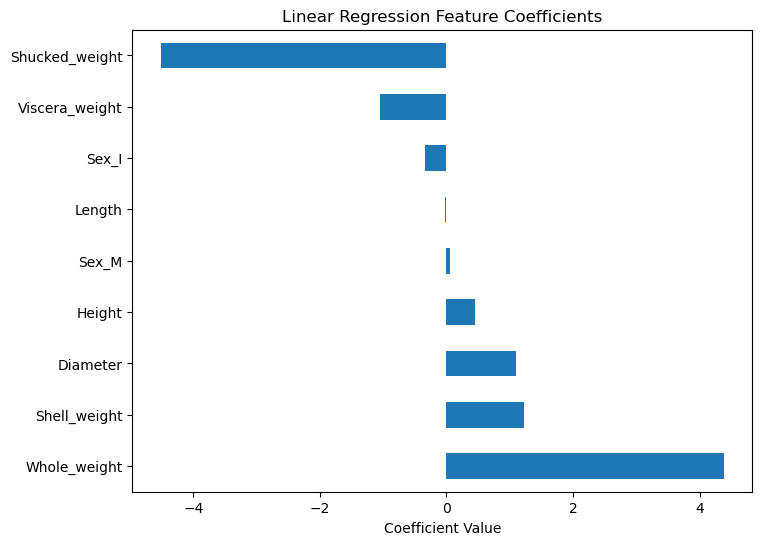

In [77]:
plt.figure(figsize=(8, 6))
lr_coefficients.plot(kind="barh")
plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient Value")
plt.show()

## Random Forest Regression Training

In [79]:
rf_model = RandomForestRegressor(n_estimators=100,random_state=42) # here we use unscalled data 

rf_model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
y_rf_pred = rf_model.predict(X_test)

In [81]:
rf_mae = mean_absolute_error(y_test, y_rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_rf_pred))
rf_r2 = r2_score(y_test, y_rf_pred)

rf_mae, rf_rmse, rf_r2

(1.5895933014354064, np.float64(2.2638382531363934), 0.5265714369702403)

In [82]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

rf_importance


Shell_weight      0.498179
Shucked_weight    0.169234
Whole_weight      0.079350
Viscera_weight    0.067453
Diameter          0.054832
Height            0.054346
Length            0.049942
Sex_I             0.018750
Sex_M             0.007914
dtype: float64

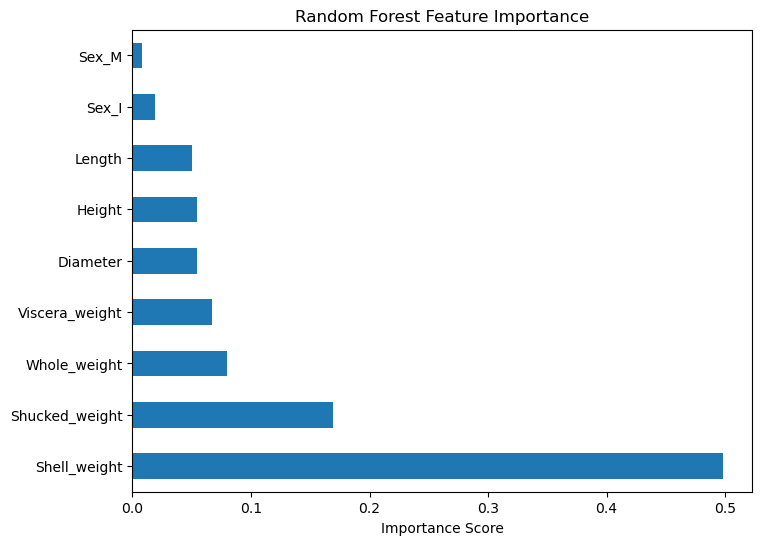

In [83]:
plt.figure(figsize=(8, 6))
rf_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()

## Support Vector Regression (SVR) Training

In [85]:
svr_model = SVR(kernel="rbf")
svr_model.fit(X_train_scaled, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [86]:
y_svr_pred = svr_model.predict(X_test_scaled)

In [87]:
svr_mae = mean_absolute_error(y_test, y_svr_pred)
svr_rmse = np.sqrt(mean_squared_error(y_test, y_svr_pred))
svr_r2 = r2_score(y_test, y_svr_pred)

svr_mae, svr_rmse, svr_r2

(1.5134401370706116, np.float64(2.2288427659068137), 0.5410952716641475)

# MODEL COMPARISON & RESULTS VISUALIZATION

## Create Model Comparison Table

In [90]:
results_df = pd.DataFrame({
    "Model": [
        "Dummy Regressor",
        "Linear Regression",
        "Random Forest",
        "Support Vector Regression"
    ],
    "MAE": [
        dummy_mae,
        lr_mae,
        rf_mae,
        svr_mae
    ],
    "RMSE": [
        dummy_rmse,
        lr_rmse,
        rf_rmse,
        svr_rmse
    ],
    "R2 Score": [
        dummy_r2,
        lr_r2,
        rf_r2,
        svr_r2
    ]
})

results_df

,Model,MAE,RMSE,R2 Score
0,Dummy Regressor,2.384770,3.290623,-0.000276
1,Linear Regression,1.593107,2.211613,0.548163
2,Random Forest,1.589593,2.263838,0.526571
3,Support Vector Regression,1.513440,2.228843,0.541095


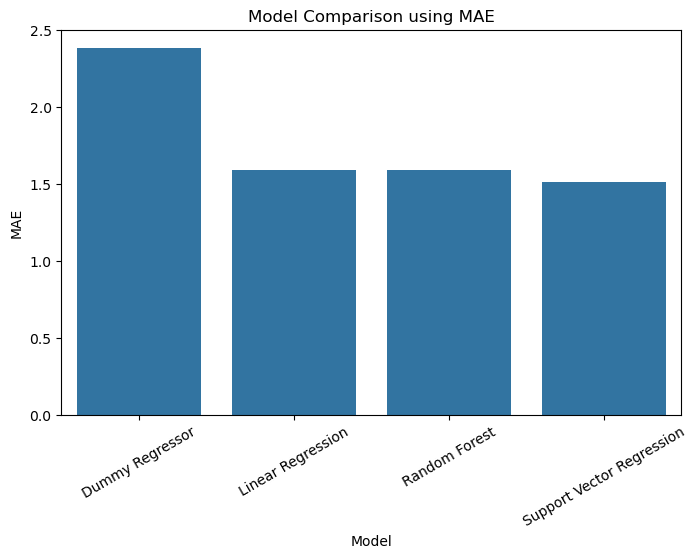

In [91]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="MAE", data=results_df)
plt.title("Model Comparison using MAE")
plt.xticks(rotation=30)
plt.show()

## RMSE Bar Plot 

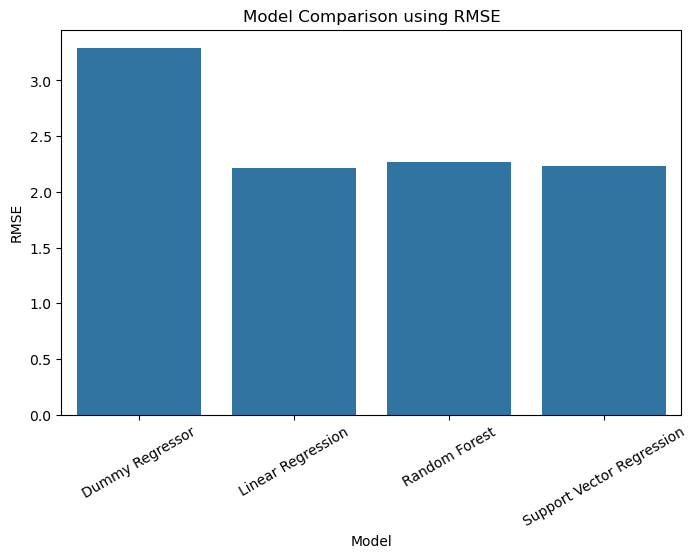

In [93]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="RMSE", data=results_df)
plt.title("Model Comparison using RMSE")
plt.xticks(rotation=30)
plt.show()

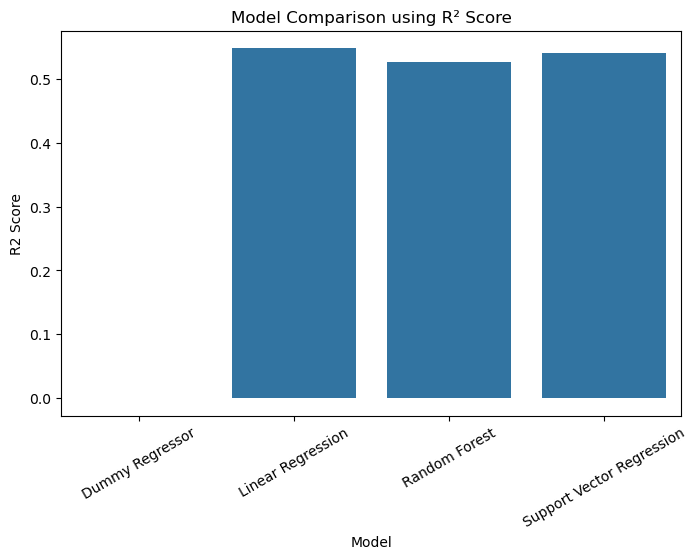

In [94]:
plt.figure(figsize=(8, 5))
sns.barplot(x="Model", y="R2 Score", data=results_df)
plt.title("Model Comparison using R² Score")
plt.xticks(rotation=30)
plt.show()

# ERROR ANALYSIS & FINAL CONCLUSION

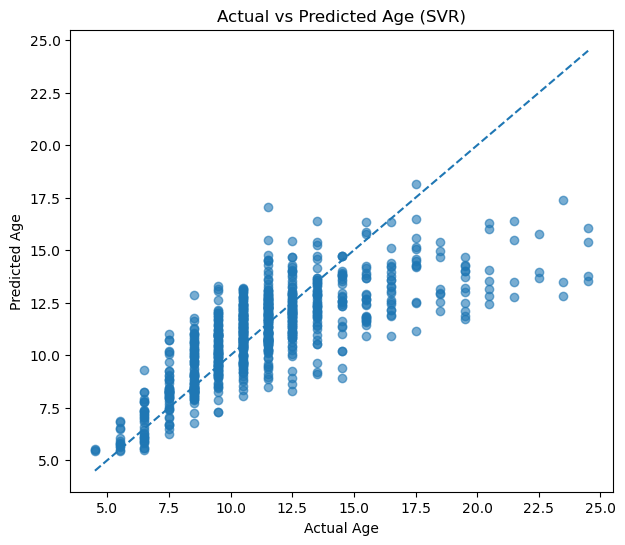

In [96]:
# Actual vs predicted plot 
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_svr_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle="--")
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Actual vs Predicted Age (SVR)")
plt.show()

In [97]:
svr_residuals = y_test - y_svr_pred

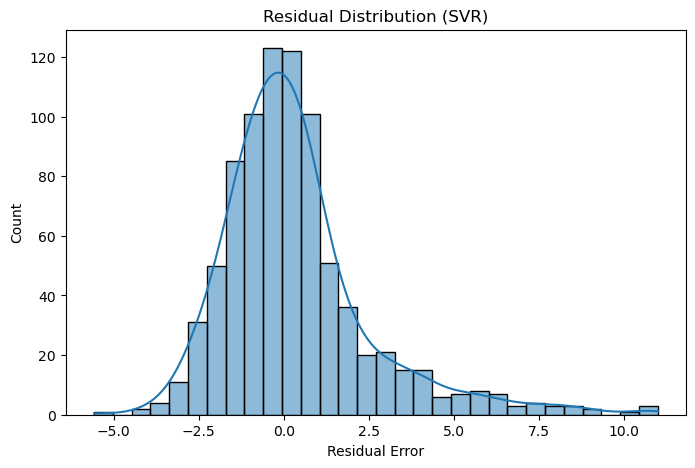

In [98]:
plt.figure(figsize=(8, 5))
sns.histplot(svr_residuals, bins=30, kde=True)
plt.title("Residual Distribution (SVR)")
plt.xlabel("Residual Error")
plt.show()

In [99]:
residuals = {
    "Linear Regression": y_test - y_lr_pred,
    "Random Forest": y_test - y_rf_pred,
    "SVR": y_test - y_svr_pred
}

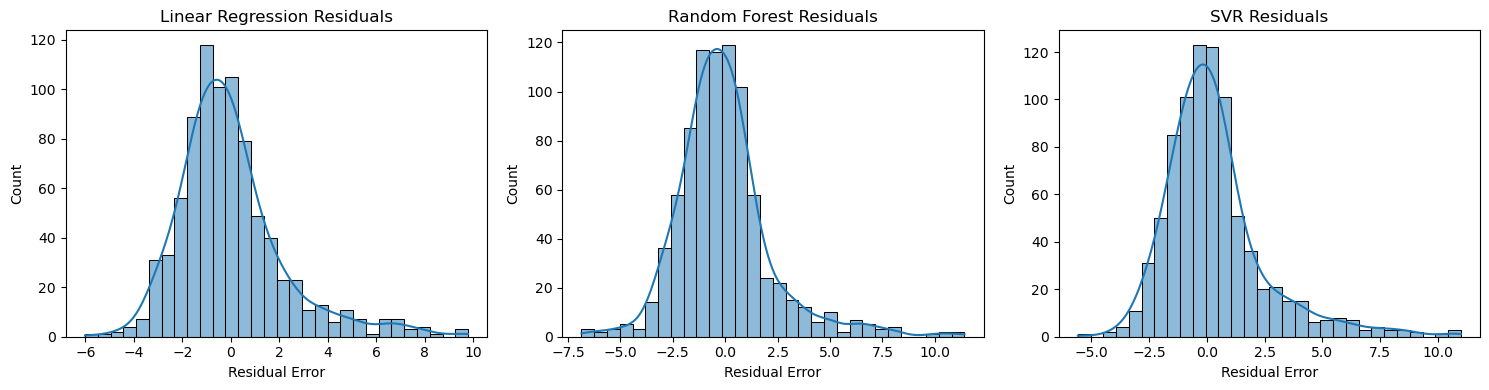

In [100]:
plt.figure(figsize=(15, 4))

for i, (model, res) in enumerate(residuals.items(), 1):
    plt.subplot(1, 3, i)
    sns.histplot(res, bins=30, kde=True)
    plt.title(f"{model} Residuals")
    plt.xlabel("Residual Error")

plt.tight_layout()
plt.show()

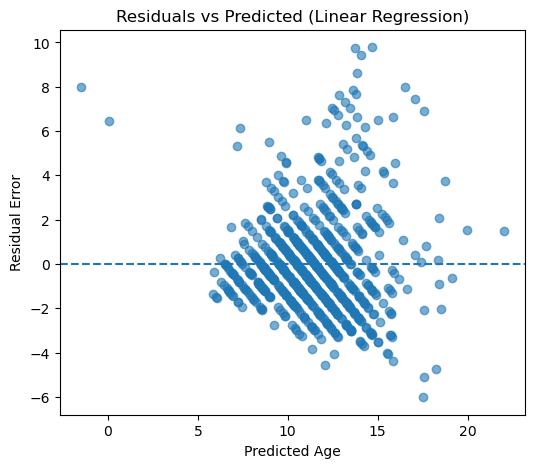

In [101]:
plt.figure(figsize=(6, 5))
plt.scatter(y_lr_pred, y_test - y_lr_pred, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Age")
plt.ylabel("Residual Error")
plt.title("Residuals vs Predicted (Linear Regression)")
plt.show()

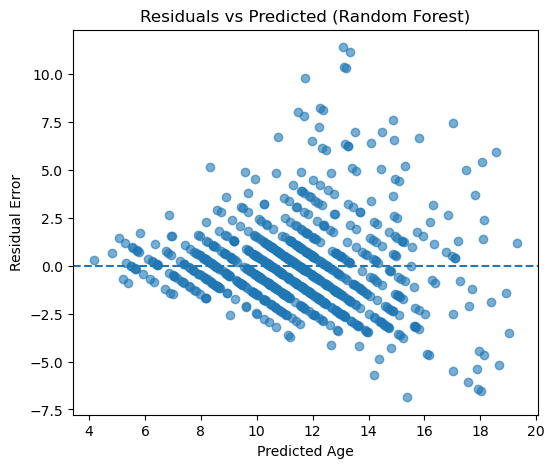

In [102]:
plt.figure(figsize=(6, 5))
plt.scatter(y_rf_pred, y_test - y_rf_pred, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Age")
plt.ylabel("Residual Error")
plt.title("Residuals vs Predicted (Random Forest)")
plt.show()

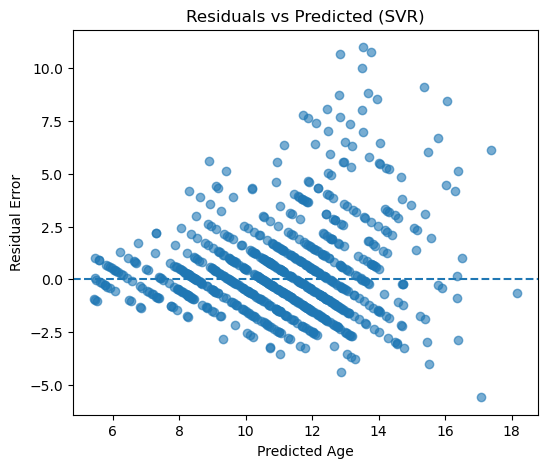

In [103]:
plt.figure(figsize=(6, 5))
plt.scatter(y_svr_pred, y_test - y_svr_pred, alpha=0.6)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Age")
plt.ylabel("Residual Error")
plt.title("Residuals vs Predicted (SVR)")
plt.show()